In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
df = pd.read_csv(
    "../data/raw/HAM10000_metadata.csv"
)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
print(df.shape)

df.info()

(10015, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [5]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [6]:
df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

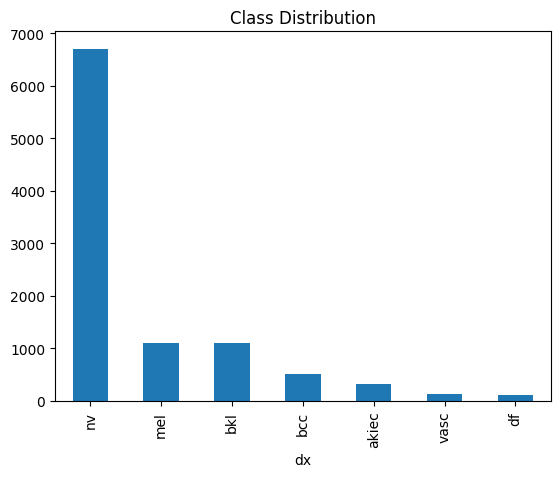

In [7]:
df["dx"].value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")

plt.show()

In [8]:
from pathlib import Path

part1 = Path(
    "../data/raw/HAM10000_images_part_1"
)

part2 = Path(
    "../data/raw/HAM10000_images_part_2"
)

In [9]:
image_paths = {}

for p in part1.glob("*.jpg"):
    image_paths[p.stem] = str(p)

for p in part2.glob("*.jpg"):
    image_paths[p.stem] = str(p)

len(image_paths)

10015

In [10]:
df["path"] = df["image_id"].map(
    image_paths.get
)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,..\data\raw\HAM10000_images_part_1\ISIC_002741...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,..\data\raw\HAM10000_images_part_1\ISIC_002503...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,..\data\raw\HAM10000_images_part_1\ISIC_002676...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,..\data\raw\HAM10000_images_part_1\ISIC_002566...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,..\data\raw\HAM10000_images_part_2\ISIC_003163...


In [11]:
df["path"].isnull().sum()

np.int64(0)

In [12]:
label_map = {
    "akiec":0,
    "bcc":1,
    "bkl":2,
    "df":3,
    "mel":4,
    "nv":5,
    "vasc":6
}

df["label"] = df["dx"].map(
    label_map
)

In [13]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,..\data\raw\HAM10000_images_part_1\ISIC_002741...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,..\data\raw\HAM10000_images_part_1\ISIC_002503...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,..\data\raw\HAM10000_images_part_1\ISIC_002676...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,..\data\raw\HAM10000_images_part_1\ISIC_002566...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,..\data\raw\HAM10000_images_part_2\ISIC_003163...,2


In [14]:
df["lesion_id"].nunique()

7470

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
lesions = df["lesion_id"].unique()

len(lesions)

7470

In [17]:
train_lesions, temp_lesions = train_test_split(
    lesions,
    test_size=0.30,
    random_state=42
)

In [18]:
val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.50,
    random_state=42
)

In [19]:
train_df = df[
    df["lesion_id"].isin(train_lesions)
]

val_df = df[
    df["lesion_id"].isin(val_lesions)
]

test_df = df[
    df["lesion_id"].isin(test_lesions)
]

In [20]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

6987
1512
1516


In [21]:
set(train_df["lesion_id"]).intersection(
    test_df["lesion_id"]
)

set()

In [22]:
train_df.to_csv(
    "../data/metadata/train.csv",
    index=False
)

val_df.to_csv(
    "../data/metadata/val.csv",
    index=False
)

test_df.to_csv(
    "../data/metadata/test.csv",
    index=False
)

In [23]:
import os

os.listdir("../data/metadata")

['test.csv', 'train.csv', 'val.csv']